In [1]:
import sys
import os
sys.path.append(os.path.abspath("/data/I6347325/work_space/STORM"))

In [2]:
import os
import gymnasium
import minigrid
from collections import deque
from functools import partial
from tqdm import tqdm
import numpy as np
import cv2
import torch
from einops import rearrange
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import colorama
from sub_models.constants import DEVICE
import glob

from sub_models.world_models import WorldModel
import sub_models.agents as agents
from utils import seed_np_torch, load_config
from train import build_world_model, build_agent
from env_wrapper import LifeLossInfo
import train

/home/I6347325/miniconda3/envs/env_RL/lib/python3.13/site-packages/torchrl/data/replay_buffers/samplers.py:34: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


In [3]:
class RunParams:
    def __init__(self, env_names, run_name: str, config_path):
        self.run_name = run_name
        self.seed = 1
        self.config_path = config_path
        # self.trajectory_path = f"D_TRAJ/{self._env_name}.pkl"
        self.env_names = env_names

        self.conf = load_config(self.config_path)
        self.print_args()

    def print_args(self):
        print(colorama.Fore.GREEN + "Arguments:" + colorama.Style.RESET_ALL)
        print(colorama.Fore.GREEN + "-----------------" + colorama.Style.RESET_ALL)
        print(
            colorama.Fore.GREEN
            + "run_name: "
            + colorama.Style.RESET_ALL
            + self.run_name
        )
        print(
            colorama.Fore.GREEN + "seed: " + colorama.Style.RESET_ALL + str(self.seed)
        )
        # print(colorama.Fore.GREEN + "config_path: " + colorama.Style.RESET_ALL + self.config_path)
        print(colorama.Fore.GREEN + "env_name: " + colorama.Style.RESET_ALL)
        print(self.env_names)
        print(colorama.Fore.GREEN + "-----------------" + colorama.Style.RESET_ALL)


def process_visualize(img):
    img = img.astype("uint8")
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (640, 640))
    return img


def build_single_env(env_name: str, image_size: int, env_observablity: str = "Full"):
    """
    Build a single env with wrappers and preprocesses env.
    """
    env = gymnasium.make(env_name, render_mode="rgb_array")
    # Convert int to tuple as gymnasium.wrappers.ResizeObservation requires tuple
    if isinstance(image_size, int):
        image_size = (image_size, image_size)
    if env_observablity == "Full":
        env = minigrid.wrappers.RGBImgObsWrapper(env)
    elif env_observablity == "Partial":
        env = minigrid.wrappers.RGBImgPartialObsWrapper(env)
    else:
        raise ValueError(f"Unknown env observability {env_observablity}")
    env = minigrid.wrappers.ImgObsWrapper(env)  # Sets obs = obs["rgb"], discards others
    env = gymnasium.wrappers.ResizeObservation(env, shape=image_size)
    # env = env_wrapper.LifeLossInfo(env)

    return env


def build_vec_env(env_names: list[str], image_size: int, env_observablity):
    """
    Build a vectorized env with n=num_envs parallel envs.
    """
    env_fns = [
        partial(build_single_env, env_name, image_size, env_observablity)
        for env_name in env_names
    ]
    vec_env = gymnasium.vector.AsyncVectorEnv(env_fns=env_fns)
    return vec_env



In [5]:
def inspect_model(
    env_names: list[str],
    max_steps: int,
    env_observablity: str,
    image_size: int,
    world_model: WorldModel,
    agent: agents.ActorCriticAgent,
    imagine_batch_length: int = 32,
    save_obs: bool = False,
    run_name: str = "default_run_name",
):
    env_names_map = {
        "MiniGrid-Empty-8x8-v0": "Empty",
        "MiniGrid-SimpleCrossingS9N1-v0": "Crossing",
        "MiniGrid-FourRooms-v0": "FourRooms",
        "MiniGrid-MemoryS11-v0": "Memory"
    }
    world_model.eval()
    agent.eval()
    vec_env = build_vec_env(env_names, image_size, env_observablity)

    num_envs = len(env_names)
    sum_reward = np.zeros(num_envs)
    current_obs, _ = vec_env.reset()
    context_obs = deque(maxlen=imagine_batch_length)
    context_action = deque(maxlen=imagine_batch_length)

    episode_counts =0
    final_rewards = []
    hidden_feats_env = []
    embeddings, labels = [], []

    while episode_counts<= max_steps:
        with torch.no_grad():
            if len(context_action) == 0:
                action = vec_env.action_space.sample()
            else:
                context_latent = world_model.encode_obs(
                    torch.cat(list(context_obs), dim=1)
                )
                model_context_action = np.stack(list(context_action), axis=1)
                model_context_action = torch.Tensor(model_context_action).to(DEVICE)
                prior_flattened_sample, last_dist_feat = (
                    world_model.calc_last_dist_feat(
                        context_latent, model_context_action
                    )
                )
                action = agent.sample_as_env_action(
                    torch.cat([prior_flattened_sample, last_dist_feat], dim=-1),
                    greedy=False,
                )

        context_obs.append(
            rearrange(torch.Tensor(current_obs).to(DEVICE), "B H W C -> B 1 C H W")
            / 255
        )
        context_action.append(action)
        # take a step in the environment
        obs, reward, done, truncated, info = vec_env.step(action)

        # save the observation frames of each env if required
        if save_obs:
            for i in range(num_envs):
                env_name = env_names_map[env_names[i]]
                env_folder = f"./frames/{run_name}/{env_name}"
                os.makedirs(env_folder, exist_ok=True)
                frame = process_visualize(obs[i])
                frame_path = os.path.join(env_folder, f"step_{episode_counts}.png")
                cv2.imwrite(frame_path, frame)

        # check if the episode is done
        done_flag = np.logical_or(done, truncated)
        if done_flag.any():
            for i in range(num_envs):
                if done_flag[i]:
                    final_rewards.append(sum_reward[i])
                    # sum_reward[i] = 0

        ## Extarcting embeddings for TSNE
        # if some logic to save embeddings
        with torch.no_grad():
            context_latent = world_model.encode_obs(
                torch.cat(list(context_obs), dim=1)
            ).to(DEVICE)  # get sample context latent
            model_context_action = torch.Tensor(
                np.stack(list(context_action), axis=1)
            ).to(DEVICE)
            hidden_feats = world_model.storm_transformer(
                context_latent, model_context_action, None,
            ).to(DEVICE)
            # incremenetally adds up [1,1,H] [1,2,H] [1,3,H] ... [1,N,H]
        # update current_obs, current_info and sum_reward
        sum_reward += reward
        current_obs = obs
        episode_counts += 1

    # [num_envs, steps, H]
    env_emb = hidden_feats.cpu().numpy()
    
    for i in range(env_emb.shape[0]):  # num_envs
        embeddings.append(env_emb[i]) # list of [steps, H]
        labels.append(env_names_map[env_names[i]])   
    return sum_reward, embeddings, labels

def get_env_embddings(run_params, ckpt_root, model_steps, max_episode=16, save_obs=False): 
    # set seed
    seed_np_torch(seed=0)

    # build and load model/agent
    dummy_env = build_single_env(
        run_params.env_names[0], run_params.conf.BasicSettings.ImageSize
    )
    action_dim = dummy_env.action_space.n
    world_model = build_world_model(run_params.conf, action_dim)
    agent = build_agent(run_params.conf, action_dim)

    rewards = []
    embeddings = []
    labels = []
    for step in tqdm(model_steps):
        world_model.load_state_dict(
            torch.load(f"{ckpt_root}/world_model_{step}.pth", map_location=DEVICE)
        )
        agent.load_state_dict(
            torch.load(f"{ckpt_root}/agent_{step}.pth", map_location=DEVICE)
        )
        rewards_step, embeddings_step, labels_step = inspect_model(
            env_names=run_params.env_names,
            max_steps=max_episode,
            env_observablity=run_params.conf.BasicSettings.EnvObservability,
            image_size=run_params.conf.BasicSettings.ImageSize,
            world_model=world_model,
            agent=agent,
            imagine_batch_length=run_params.conf.JointTrainAgent.ImagineBatchLength,
            save_obs= save_obs,
            run_name=run_params.run_name,
        )
        # append "_step" to the labels
        labels_step = [f"{label}_{step}" for label in labels_step]    
        rewards.extend(rewards_step)
        embeddings.extend(embeddings_step)
        labels.extend(labels_step)
    return embeddings, labels

def calculate_TSNE(embeddings, max_episode=16):
    # ---- t-SNE ----
    emb = np.array(embeddings)
    emb = emb.reshape(-1, emb.shape[-1])  # [num_envs, steps, H] -> [num_envs*steps, H]
    tsne = TSNE(n_components=2, perplexity = 16, learning_rate=200) #perplexity=8,
    emb_2d = tsne.fit_transform(emb)
    emb_2d = emb_2d.reshape(-1, max_episode+1, 2) # reshape to [num_envs, steps, 2]
    return emb_2d

# MultiEnv Vs Individual Runs

In [6]:
env_names = [
        "MiniGrid-Empty-8x8-v0",
        "MiniGrid-SimpleCrossingS9N1-v0",
        "MiniGrid-FourRooms-v0",
        "MiniGrid-MemoryS11-v0",
    ]
seed = 0
RUN_NAME = "MultiEnvFullObs-Baseline_v1" #"EmptyFullObs-Baseline_v1" # "MemoryFullObs-Baseline_v1" #
ckpt_root = f"../ckpt/{RUN_NAME}/"
config_path = f"../config_files/STORM.yaml"
STEP = 65000# 73750

In [7]:
RUN_NAME = "MultiEnvFullObs-Baseline_v1"
ckpt_root = f"../ckpt/{RUN_NAME}/"
model_steps = [65000]  
run_params = RunParams(env_names, RUN_NAME, config_path)
multifull_emb, multifull_labels = get_env_embddings(run_params, ckpt_root, model_steps, max_episode=16,save_obs=False)
# import pickle
# # Save rewards, embeddings, labels to a pickle file
# with open("env_tsne_data.pkl", "wb") as f:
#     pickle.dump((rewards, embeddings, labels), f)
# import pickle
# # Reload rewards, embeddings, labels from the pickle file
# with open("env_tsne_data.pkl", "rb") as f:
    # rewards, embeddings, labels = pickle.load(f)

multifull_emb_2d = calculate_TSNE(multifull_emb, max_episode=16)

Arguments:
-----------------
run_name: MultiEnvFullObs-Baseline_v1
seed: 1
env_name: 
['MiniGrid-Empty-8x8-v0', 'MiniGrid-SimpleCrossingS9N1-v0', 'MiniGrid-FourRooms-v0', 'MiniGrid-MemoryS11-v0']
-----------------


100%|██████████| 1/1 [00:01<00:00,  1.25s/it]


In [8]:
env_names = [
        "MiniGrid-Empty-8x8-v0",
        # "MiniGrid-SimpleCrossingS9N1-v0",
        # "MiniGrid-FourRooms-v0",
        # "MiniGrid-MemoryS11-v0",
    ]
RUN_NAME = "MultiEnvFullObs-Baseline_v1"
ckpt_root = f"../ckpt/{RUN_NAME}/"
model_steps = [7500]  
run_params = RunParams(env_names, RUN_NAME, config_path)
empty_full_emb, empty_full_labels = get_env_embddings(run_params, ckpt_root, model_steps, max_episode=16, save_obs=False)
empty_full_emb_2d = calculate_TSNE(empty_full_emb, max_episode=16)

Arguments:
-----------------
run_name: MultiEnvFullObs-Baseline_v1
seed: 1
env_name: 
['MiniGrid-Empty-8x8-v0']
-----------------


100%|██████████| 1/1 [00:00<00:00,  1.62it/s]


In [9]:
labels = multifull_labels 
multi_env_emb2d = multifull_emb_2d[0] # single env embeddings from multi env
indiviudal_env_emb2d = empty_full_emb_2d[0]
title = "Empty"

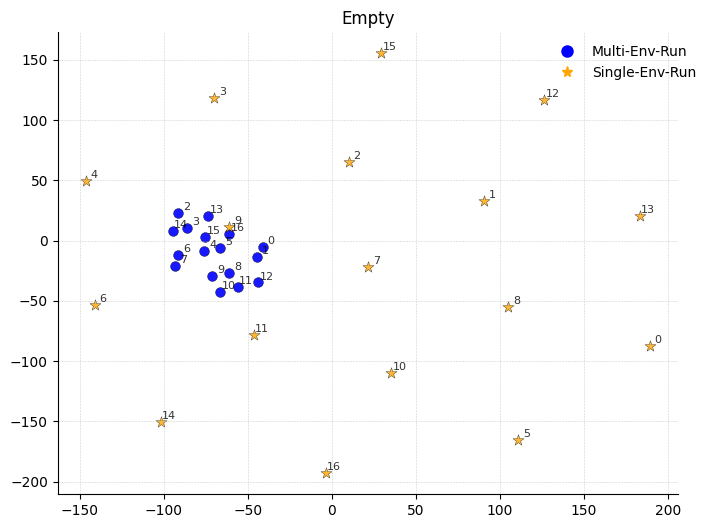

In [10]:
# Extract environment name and training step
env_names = [labels[i].split('_')[0] for i in range(len(labels))]
steps = np.arange(0,multi_env_emb2d.shape[0])

# Unique environments and marker shapes
# unique_envs = sorted(set(env_names))
# marker_styles = ['o', 'X', '*', '^', 'v', '<', '>', 'P', '*','D', 's']
# env_marker_map = {env: marker_styles[i % len(marker_styles)] for i, env in enumerate(unique_envs)}

# Color gradient
norm = mcolors.Normalize(vmin=steps.min(), vmax=steps.max())
cmap = plt.get_cmap("plasma") #viridis
colors = cmap(norm(steps))

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
# Plot points of the first embeddings 

ax.scatter(
    multi_env_emb2d[:, 0],
    multi_env_emb2d[:, 1],
    c="blue",
    marker="o",
    edgecolors="k",
    linewidths=0.3,
    s=50,
    alpha=0.9,
)
# Annotate each point with its step number
for j, step in enumerate(steps):
    ax.annotate(
        str(step),
        (multi_env_emb2d[j, 0] + 5, multi_env_emb2d[j, 1] + 5),
        fontsize=8,
        ha="center",
        va="center",
        alpha=0.8,
    )
ax.scatter(
    indiviudal_env_emb2d[:, 0],
    indiviudal_env_emb2d[:, 1],
    c="orange",
    marker="*",
    edgecolors="k",
    linewidths=0.3,
    s=70,
    alpha=0.8,
)
# Annotate each point with its step number
for j, step in enumerate(steps):
    ax.annotate(
        str(step),
        (indiviudal_env_emb2d[j, 0] + 5, indiviudal_env_emb2d[j, 1] + 5),
        fontsize=8,
        ha="center",
        va="center",
        alpha=0.8,
    )
# Create legend for environments
legend_handles = [
    plt.Line2D(
        [], [], color='blue', marker="o", linestyle='', label="Multi-Env-Run", markersize=8
    ),
    plt.Line2D(
        [], [], color='orange', marker="*", linestyle='', label="Single-Env-Run", markersize=8
    )   
]
ax.legend(
    handles=legend_handles,
    # title",
    loc="best",
    bbox_to_anchor=(1.05, 1),
    frameon=False,
)
ax.set_title(title, fontsize=12)
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=10)
# fig.tight_layout()
plt.show()


In [11]:
env_names = [
        # "MiniGrid-Empty-8x8-v0",
        "MiniGrid-SimpleCrossingS9N1-v0",
        # "MiniGrid-FourRooms-v0",
        # "MiniGrid-MemoryS11-v0",
    ]
RUN_NAME = "SimpleCross-FullObs-Baseline-v4"
ckpt_root = f"../ckpt/{RUN_NAME}/"
model_steps = [50000]  
run_params = RunParams(env_names, RUN_NAME, config_path)
cross_full_emb, cross_full_labels = get_env_embddings(run_params, ckpt_root, model_steps, max_episode=16, save_obs=True)
cross_full_emb_2d = calculate_TSNE(cross_full_emb, max_episode=16)

Arguments:
-----------------
run_name: SimpleCross-FullObs-Baseline-v4
seed: 1
env_name: 
['MiniGrid-SimpleCrossingS9N1-v0']
-----------------


100%|██████████| 1/1 [00:00<00:00,  1.48it/s]


In [13]:
labels = multifull_labels 
multi_env_emb2d = multifull_emb_2d[0] # single env embeddings from multi env
indiviudal_env_emb2d = cross_full_emb_2d[0]
title = "simple crossing"

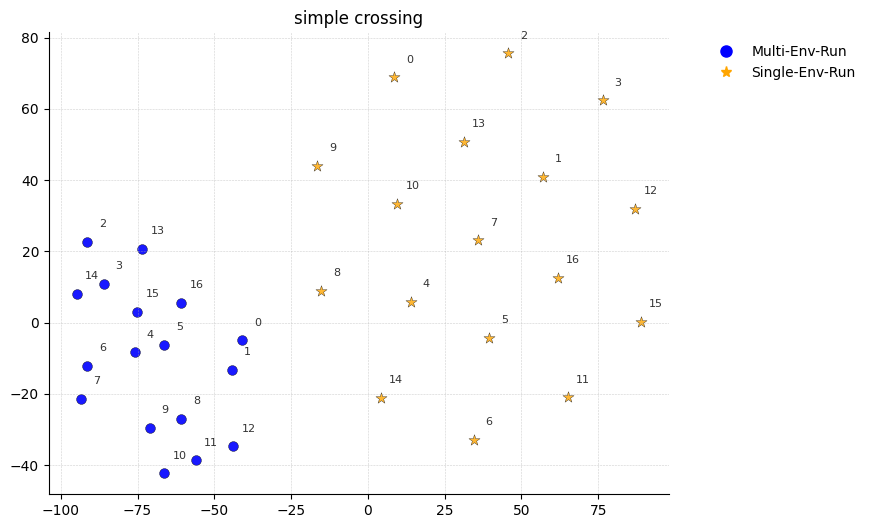

In [14]:
# Extract environment name and training step
env_names = [labels[i].split('_')[0] for i in range(len(labels))]
steps = np.arange(0,multi_env_emb2d.shape[0])

# Unique environments and marker shapes
# unique_envs = sorted(set(env_names))
# marker_styles = ['o', 'X', '*', '^', 'v', '<', '>', 'P', '*','D', 's']
# env_marker_map = {env: marker_styles[i % len(marker_styles)] for i, env in enumerate(unique_envs)}

# Color gradient
norm = mcolors.Normalize(vmin=steps.min(), vmax=steps.max())
cmap = plt.get_cmap("plasma") #viridis
colors = cmap(norm(steps))

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
# Plot points of the first embeddings 

ax.scatter(
    multi_env_emb2d[:, 0],
    multi_env_emb2d[:, 1],
    c="blue",
    marker="o",
    edgecolors="k",
    linewidths=0.3,
    s=50,
    alpha=0.9,
)
# Annotate each point with its step number
for j, step in enumerate(steps):
    ax.annotate(
        str(step),
        (multi_env_emb2d[j, 0] + 5, multi_env_emb2d[j, 1] + 5),
        fontsize=8,
        ha="center",
        va="center",
        alpha=0.8,
    )
ax.scatter(
    indiviudal_env_emb2d[:, 0],
    indiviudal_env_emb2d[:, 1],
    c="orange",
    marker="*",
    edgecolors="k",
    linewidths=0.3,
    s=70,
    alpha=0.8,
)
# Annotate each point with its step number
for j, step in enumerate(steps):
    ax.annotate(
        str(step),
        (indiviudal_env_emb2d[j, 0] + 5, indiviudal_env_emb2d[j, 1] + 5),
        fontsize=8,
        ha="center",
        va="center",
        alpha=0.8,
    )
# Create legend for environments
legend_handles = [
    plt.Line2D(
        [], [], color='blue', marker="o", linestyle='', label="Multi-Env-Run", markersize=8
    ),
    plt.Line2D(
        [], [], color='orange', marker="*", linestyle='', label="Single-Env-Run", markersize=8
    )   
]
ax.legend(
    handles=legend_handles,
    # title",
    loc="best",
    bbox_to_anchor=(1.05, 1),
    frameon=False,
)
ax.set_title(title, fontsize=12)
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=10)
# fig.tight_layout()
plt.show()


# Compariosn of Frames with TSNE

In [ ]:
def plot_envframes_tsne(emb_2d, labels, title):
    """
    Plot the t-SNE embeddings with different marker shapes for environments
    and a color gradient for training steps.
    Args:
        emb_2d (np.ndarray): shape (num_envs, steps, 2) - t-SNE embeddings
        labels (list): list of environment names 
    """
    # Extract environment name and training step
    env_names = [labels[i].split('_')[0] for i in range(len(labels))]
    steps = np.arange(0,emb_2d.shape[1]) 

    # Unique environments and marker shapes
    unique_envs = sorted(set(env_names))
    marker_styles = ['o', 'X', '*', '^', 'v', '<', '>', 'P', '*','D', 's']
    env_marker_map = {env: marker_styles[i % len(marker_styles)] for i, env in enumerate(unique_envs)}

    # Color gradient
    norm = mcolors.Normalize(vmin=steps.min(), vmax=steps.max())
    cmap = plt.get_cmap("plasma") #viridis

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))
    # Plot points with appropriate shape and color
    for i in range(emb_2d.shape[0]):  # num_envs
        env = env_names[i]
        marker = env_marker_map[env]
        colors = cmap(norm(steps))
        ax.scatter(
            emb_2d[i, :, 0],
            emb_2d[i, :, 1],
            c=colors,
            marker=marker,
            edgecolors="k",
            linewidths=0.3,
            s=70,
            alpha=0.9,
        )
        # Annotate each point with its step number
        for j, step in enumerate(steps):
            ax.annotate(
                str(step),
                (emb_2d[i, j, 0]+5, emb_2d[i, j, 1] + 5),
                fontsize=8,
                ha="center",
                va="center",
                alpha=0.8,
            )
    # Create legend for environments
    legend_handles = [
        plt.Line2D(
            [], [], color='blue', marker=env_marker_map[env], linestyle='', label=env, markersize=8
        )
        for env in unique_envs
    ]
    ax.legend(
        handles=legend_handles,
        title="Environment",
        loc="best",
        bbox_to_anchor=(1.05, 1),
        frameon=False,
    )

    # Colorbar for steps
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Dummy array just to keep matplotlib happy
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Training Checkpoints")

    # Beautify
    ax.set_title(title, fontsize=12)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)
    # fig.tight_layout()
    plt.show()


    # # Add colorbar to the figure
    # sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])
    # cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.80, pad=0.03)
    # cbar.set_label("WM Training Checkpoints")

    # fig.suptitle(main_title, fontsize=12)
    # # fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    # plt.show()


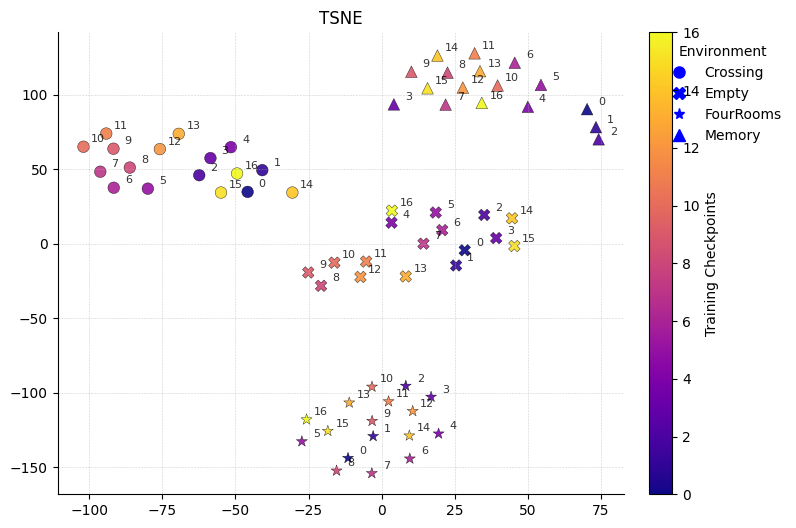

In [18]:
plot_envframes_tsne(emb_2d, labels, "TSNE")

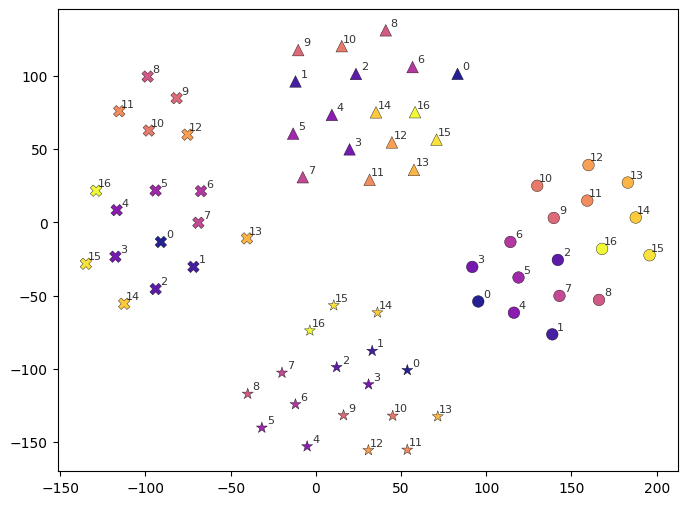

In [25]:
# Extract environment name and training step
env_names = labels
steps = np.arange(0,emb_2d.shape[1])

# Unique environments and marker shapes
unique_envs = sorted(set(env_names))
marker_styles = ['o', 'X', '*', '^', 'v', '<', '>', 'P', '*','D', 's']
env_marker_map = {env: marker_styles[i % len(marker_styles)] for i, env in enumerate(unique_envs)}

# Color gradient
norm = mcolors.Normalize(vmin=steps.min(), vmax=steps.max())
cmap = plt.get_cmap("plasma") #viridis

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
# Plot points with appropriate shape and color
for i in range(emb_2d.shape[0]):  # num_envs
    env = env_names[i]
    marker = env_marker_map[env]
    colors = cmap(norm(steps))
    ax.scatter(
        emb_2d[i, :, 0],
        emb_2d[i, :, 1],
        c=colors,
        marker=marker,
        edgecolors="k",
        linewidths=0.3,
        s=70,
        alpha=0.9,
    )
    # Annotate each point with its step number
    for j, step in enumerate(steps):
        ax.annotate(
            str(step),
            (emb_2d[i, j, 0]+5, emb_2d[i, j, 1] + 5),
            fontsize=8,
            ha="center",
            va="center",
            alpha=0.8,
        )

# TSNE for all steps models

## Broken Down code

In [7]:
USE_MEAN_POOL = True  # or False for last token
EPISODES_PER_ENV = 16
env_names = [
        # "ALE/MsPacman-v5",
        "MiniGrid-Empty-8x8-v0",
        "MiniGrid-SimpleCrossingS9N1-v0",
        "MiniGrid-FourRooms-v0",
        "MiniGrid-MemoryS11-v0",
        ## "MiniGrid-RedBlueDoors-6x6-v0",
        # "MiniGrid-Empty-Random-6x6-v0",
    ]
seed = 0
RUN_NAME = "MultiEnvFullObs-Baseline_v1" #"EmptyFullObs-Baseline_v1" # "MemoryFullObs-Baseline_v1" #
ckpt_root = f"../ckpt/{RUN_NAME}/"
config_path = f"../config_files/STORM.yaml"

run_params = RunParams(env_names, RUN_NAME, config_path)
# set seed
seed_np_torch(seed=seed)

# build and load model/agent
dummy_env = build_single_env(
    run_params.env_names[0], run_params.conf.BasicSettings.ImageSize
)
action_dim = dummy_env.action_space.n
world_model = build_world_model(run_params.conf, action_dim)
agent = build_agent(run_params.conf, action_dim)


Arguments:
-----------------
run_name: MultiEnvFullObs-Baseline_v1
seed: 1
env_name: 
['MiniGrid-Empty-8x8-v0', 'MiniGrid-SimpleCrossingS9N1-v0', 'MiniGrid-FourRooms-v0', 'MiniGrid-MemoryS11-v0']
-----------------


In [8]:
pathes = glob.glob(f"{ckpt_root}/world_model_*.pth")
steps = [int(path.split("_")[-1].split(".")[0]) for path in pathes]
steps.sort()
print(steps)


[0, 1250, 2500, 3750, 5000, 6250, 7500, 8750, 10000, 11250, 12500, 13750, 15000, 16250, 17500, 18750, 20000, 21250, 22500, 23750, 25000, 26250, 27500, 28750, 30000, 31250, 32500, 33750, 35000, 36250, 37500, 38750, 40000, 41250, 42500, 43750, 45000, 46250, 47500, 48750, 50000, 51250, 52500, 53750, 55000, 56250, 57500, 58750, 60000, 61250, 62500, 63750, 65000, 66250, 67500, 68750, 70000, 71250, 72500, 73750]


In [9]:
# pathes = glob.glob(f"{ckpt_root}/world_model_*.pth")
# steps = [int(path.split("_")[-1].split(".")[0]) for path in pathes]
# steps.sort()
steps = [0, 1250, 2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000, 22500, 25000, 27500, 30000, 32500, 35000, 37500, 40000, 42500, 45000, 47500, 50000, 55000, 57500, 60000, 65000, 67500, 70000]
# steps = steps[-1:]  # select the last checkpoint
print(steps)
rewards = []
embeddings = []
labels = []
for step in tqdm(steps):
    world_model.load_state_dict(
        torch.load(f"{ckpt_root}/world_model_{step}.pth", map_location=DEVICE)
    )
    agent.load_state_dict(
        torch.load(f"{ckpt_root}/agent_{step}.pth", map_location=DEVICE)
    )
    rewards_step, embeddings_step, labels_step = inspect_model(
        env_names=run_params.env_names,
        max_steps=16,
        env_observablity=run_params.conf.BasicSettings.EnvObservability,
        image_size=run_params.conf.BasicSettings.ImageSize,
        world_model=world_model,
        agent=agent,
        imagine_batch_length=run_params.conf.JointTrainAgent.ImagineBatchLength,
        show_obs= False,
    )
    # append "_step" to the labels
    labels_step = [f"{label}_{step}" for label in labels_step]    
    rewards.extend(rewards_step)
    embeddings.extend(embeddings_step)
    labels.extend(labels_step)


[0, 1250, 2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000, 22500, 25000, 27500, 30000, 32500, 35000, 37500, 40000, 42500, 45000, 47500, 50000, 55000, 57500, 60000, 65000, 67500, 70000]


100%|██████████| 28/28 [00:22<00:00,  1.26it/s]


In [ ]:
# def process_labels(label):
#     env_names_map = {
#         "MiniGrid-Empty-8x8-v0": "Empty",
#         "MiniGrid-SimpleCrossingS9N1-v0": "Crossing",
#         "MiniGrid-FourRooms-v0": "FourRooms",
#         "MiniGrid-MemoryS11-v0": "Memory"
#         }
#     return env_names_map[label.split("_")[0]] + "_"+ label.split("_")[-1]
# labels = list(map(process_labels, labels))

In [10]:
labels

['Empty_0',
 'Crossing_0',
 'FourRooms_0',
 'Memory_0',
 'Empty_1250',
 'Crossing_1250',
 'FourRooms_1250',
 'Memory_1250',
 'Empty_2500',
 'Crossing_2500',
 'FourRooms_2500',
 'Memory_2500',
 'Empty_5000',
 'Crossing_5000',
 'FourRooms_5000',
 'Memory_5000',
 'Empty_7500',
 'Crossing_7500',
 'FourRooms_7500',
 'Memory_7500',
 'Empty_10000',
 'Crossing_10000',
 'FourRooms_10000',
 'Memory_10000',
 'Empty_12500',
 'Crossing_12500',
 'FourRooms_12500',
 'Memory_12500',
 'Empty_15000',
 'Crossing_15000',
 'FourRooms_15000',
 'Memory_15000',
 'Empty_17500',
 'Crossing_17500',
 'FourRooms_17500',
 'Memory_17500',
 'Empty_20000',
 'Crossing_20000',
 'FourRooms_20000',
 'Memory_20000',
 'Empty_22500',
 'Crossing_22500',
 'FourRooms_22500',
 'Memory_22500',
 'Empty_25000',
 'Crossing_25000',
 'FourRooms_25000',
 'Memory_25000',
 'Empty_27500',
 'Crossing_27500',
 'FourRooms_27500',
 'Memory_27500',
 'Empty_30000',
 'Crossing_30000',
 'FourRooms_30000',
 'Memory_30000',
 'Empty_32500',
 'Crossi

In [ ]:
# ---- t-SNE ----
embeddings = np.array(embeddings)
tsne = TSNE(n_components=2, perplexity = 20, learning_rate=200) #perplexity=8,
emb_2d = tsne.fit_transform(embeddings)

/tmp/ipykernel_3985226/1882147623.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(unique_envs))


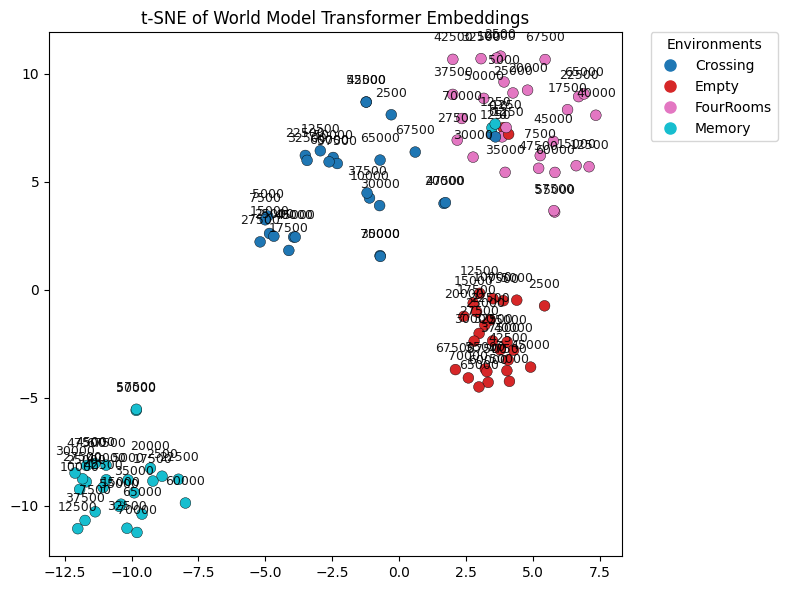

In [15]:


def plot_TSNE(emb_2d, labels, title):
    """
    Plot the t-SNE embeddings with colors based on environment names.
    """
    # Extract environment name and step from each label
    env_names = [label.split("_")[0] for label in labels]
    steps = [label.split("_")[1] for label in labels]

    # Assign a unique color index to each environment
    unique_envs = sorted(set(env_names))
    env_color_map = {env: idx for idx, env in enumerate(unique_envs)}
    colors_idx = [env_color_map[env] for env in env_names]

    # Setup colormap and normalization
    cmap = cm.get_cmap("tab10", len(unique_envs))
    norm = mcolors.Normalize(vmin=0, vmax=len(unique_envs) - 1)

    # Plot the points
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        emb_2d[:, 0],
        emb_2d[:, 1],
        c=colors_idx,
        cmap=cmap,
        norm=norm,
        s=60,
        edgecolors="k",
        linewidths=0.3,
    )

    # Annotate each point with its step value
    for i in range(len(emb_2d)):
        plt.annotate(
            steps[i],
            (emb_2d[i, 0], emb_2d[i, 1]+1),
            fontsize=9,
            alpha=0.9,
            ha="center",
            va="center",
        )

    # Create correct legend handles with exact colors
    handles = [
        plt.Line2D(
            [], [],
            marker="o",
            linestyle="",
            color=cmap(norm(env_color_map[env])),
            label=env,
            markersize=8,
        )
        for env in unique_envs
    ]
    plt.legend(
        handles=handles,
        title="Environments",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.,
    )

    plt.title(f"{title}")
    plt.tight_layout()
    plt.show()



## Clean code

In [5]:
def get_env_embddings(run_params, ckpt_root, model_steps, max_episode=16): 
    # set seed
    seed_np_torch(seed=0)

    # build and load model/agent
    dummy_env = build_single_env(
        run_params.env_names[0], run_params.conf.BasicSettings.ImageSize
    )
    action_dim = dummy_env.action_space.n
    world_model = build_world_model(run_params.conf, action_dim)
    agent = build_agent(run_params.conf, action_dim)

    rewards = []
    embeddings = []
    labels = []
    for step in tqdm(model_steps):
        world_model.load_state_dict(
            torch.load(f"{ckpt_root}/world_model_{step}.pth", map_location=DEVICE)
        )
        agent.load_state_dict(
            torch.load(f"{ckpt_root}/agent_{step}.pth", map_location=DEVICE)
        )
        rewards_step, embeddings_step, labels_step = inspect_model(
            env_names=run_params.env_names,
            max_steps=max_episode,
            env_observablity=run_params.conf.BasicSettings.EnvObservability,
            image_size=run_params.conf.BasicSettings.ImageSize,
            world_model=world_model,
            agent=agent,
            imagine_batch_length=run_params.conf.JointTrainAgent.ImagineBatchLength,
            show_obs= False,
        )
        # append "_step" to the labels
        labels_step = [f"{label}_{step}" for label in labels_step]    
        rewards.extend(rewards_step)
        embeddings.extend(embeddings_step)
        labels.extend(labels_step)
    return embeddings, labels

def calculate_TSNE(embeddings):
    # ---- t-SNE ----
    embeddings = np.array(embeddings)
    tsne = TSNE(n_components=2, perplexity = 20, learning_rate=200) #perplexity=8,
    emb_2d = tsne.fit_transform(embeddings)
    return emb_2d

def plot_TSNE(emb_2d, labels, title):
    """
    Plot the t-SNE embeddings with different marker shapes for environments
    and a color gradient for training steps.
    """
    # Extract environment name and training step
    env_names = [label.split("_")[0] for label in labels]
    steps = np.array([int(label.split("_")[1]) for label in labels])

    # Unique environments and marker shapes
    unique_envs = sorted(set(env_names))
    marker_styles = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X']
    env_marker_map = {env: marker_styles[i % len(marker_styles)] for i, env in enumerate(unique_envs)}

    # Color gradient
    norm = mcolors.Normalize(vmin=steps.min(), vmax=steps.max())
    cmap = plt.get_cmap("plasma") #viridis

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot points with appropriate shape and color
    for i in range(len(emb_2d)):
        env = env_names[i]
        step = steps[i]
        color = cmap(norm(step))
        marker = env_marker_map[env]
        ax.scatter(
            emb_2d[i, 0],
            emb_2d[i, 1],
            c=[color],
            marker=marker,
            edgecolors="k",
            linewidths=0.3,
            s=70,
            alpha=0.9,
        )
        # # Annotate with step
        # ax.annotate(
        #     str(step),
        #     (emb_2d[i, 0], emb_2d[i, 1] + 0.7),
        #     fontsize=8,
        #     ha="center",
        #     va="center",
        #     alpha=0.8,
        # )

    # Create legend for environments
    legend_handles = [
        plt.Line2D(
            [], [], color='black', marker=env_marker_map[env], linestyle='', label=env, markersize=8
        )
        for env in unique_envs
    ]
    ax.legend(
        handles=legend_handles,
        title="Environment",
        loc="best",
        bbox_to_anchor=(1.05, 1),
        frameon=False,
    )

    # Colorbar for steps
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Dummy array just to keep matplotlib happy
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Training Checkpoints")

    # Beautify
    ax.set_title(title, fontsize=12)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)
    fig.tight_layout()
    plt.show()

def plot_TSNE_side_by_side(emb_2d_1, emb_2d_2, labels, main_title, title1, title2):
    """
    Plot two t-SNE embeddings side by side with markers for environments and a color gradient for steps.
    """
    # Extract environment and step info
    env_names = [label.split("_")[0] for label in labels]
    steps = np.array([int(label.split("_")[1]) for label in labels])

    # Unique environments and marker shapes
    unique_envs = sorted(set(env_names))
    marker_styles = ['o', 'X', '*', '^', 'v', '<', '>', 'P', '*','D', 's']
    env_marker_map = {env: marker_styles[i % len(marker_styles)] for i, env in enumerate(unique_envs)}

    # Color normalization and map
    norm = mcolors.Normalize(vmin=steps.min(), vmax=steps.max())
    cmap = plt.get_cmap("plasma")

    # Create figure with 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    for idx, (emb_2d, ax, title) in enumerate(zip([emb_2d_1, emb_2d_2], axes, [title1, title2])):
        for i in range(len(emb_2d)):
            env = env_names[i]
            step = steps[i]
            color = cmap(norm(step))
            marker = env_marker_map[env]
            ax.scatter(
                emb_2d[i, 0],
                emb_2d[i, 1],
                c=[color],
                marker=marker,
                edgecolors="k",
                linewidths=0.4,
                s=70,
                alpha=0.8,
            )
            # Optional annotation of steps
            # ax.annotate(str(step), (emb_2d[i, 0], emb_2d[i, 1] + 0.7), fontsize=8, alpha=0.6)

        ax.set_title(title, fontsize=10)
        ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='both', labelsize=10)

    # Add legend to the first axis
    legend_handles = [
        plt.Line2D([], [], color='blue', marker=env_marker_map[env], linestyle='', label=env, markersize=8)
        for env in unique_envs
    ]
    axes[0].legend(
        handles=legend_handles,
        title="Environments",
        loc="best",
        frameon=False,
    )
    axes[1].legend(
        handles=legend_handles,
        title="Environments",
        loc="best",
        frameon=False,
    )

    # Add colorbar to the figure
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.80, pad=0.03)
    cbar.set_label("WM Training Checkpoints")

    fig.suptitle(main_title, fontsize=12)
    # fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## Baseline FullObs and PartialObs

In [78]:
env_names = [
        "MiniGrid-Empty-8x8-v0",
        "MiniGrid-SimpleCrossingS9N1-v0",
        "MiniGrid-FourRooms-v0",
        "MiniGrid-MemoryS11-v0",
    ]
seed = 0
config_path = f"../config_files/STORM.yaml"
# pathes = glob.glob(f"{ckpt_root}/world_model_*.pth")
# steps = [int(path.split("_")[-1].split(".")[0]) for path in pathes]
# steps.sort()
# print(steps)
steps = [0, 1250, 2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000, 22500, 25000, 27500, 30000, 32500, 35000, 37500, 40000, 42500, 45000, 47500, 50000, 55000, 57500, 60000, 65000, 67500, 70000]
len(steps)


28

In [79]:
fullobs_RUN_NAME = "MultiEnvFullObs-Baseline_v1" #"EmptyFullObs-Baseline_v1" # "MemoryFullObs-Baseline_v1" #
fullobs_ckpt_root = f"../ckpt/{fullobs_RUN_NAME}/"
fullobs_run_params = RunParams(env_names, fullobs_RUN_NAME, config_path)

fullobs_emb, fullobs_labels = get_env_embddings(fullobs_run_params, fullobs_ckpt_root, steps, max_episode=16)
fullobs_emb_2d = calculate_TSNE(fullobs_emb)

Arguments:
-----------------
run_name: MultiEnvFullObs-Baseline_v1
seed: 1
env_name: 
['MiniGrid-Empty-8x8-v0', 'MiniGrid-SimpleCrossingS9N1-v0', 'MiniGrid-FourRooms-v0', 'MiniGrid-MemoryS11-v0']
-----------------


  0%|          | 0/28 [00:00<?, ?it/s]

100%|██████████| 28/28 [00:21<00:00,  1.29it/s]


In [80]:
partialobs_RUN_NAME = "MultiEnvPartObs-Baseline_v1"
partialobs_ckpt_root = f"../ckpt/{partialobs_RUN_NAME}/"


partialobs_run_params = RunParams(env_names, partialobs_RUN_NAME, config_path)
partialobs_emb, partialobs_labels = get_env_embddings(partialobs_run_params, partialobs_ckpt_root, steps, max_episode=16)
partialobs_emb_2d = calculate_TSNE(partialobs_emb)

Arguments:
-----------------
run_name: MultiEnvPartObs-Baseline_v1
seed: 1
env_name: 
['MiniGrid-Empty-8x8-v0', 'MiniGrid-SimpleCrossingS9N1-v0', 'MiniGrid-FourRooms-v0', 'MiniGrid-MemoryS11-v0']
-----------------


100%|██████████| 28/28 [00:21<00:00,  1.32it/s]


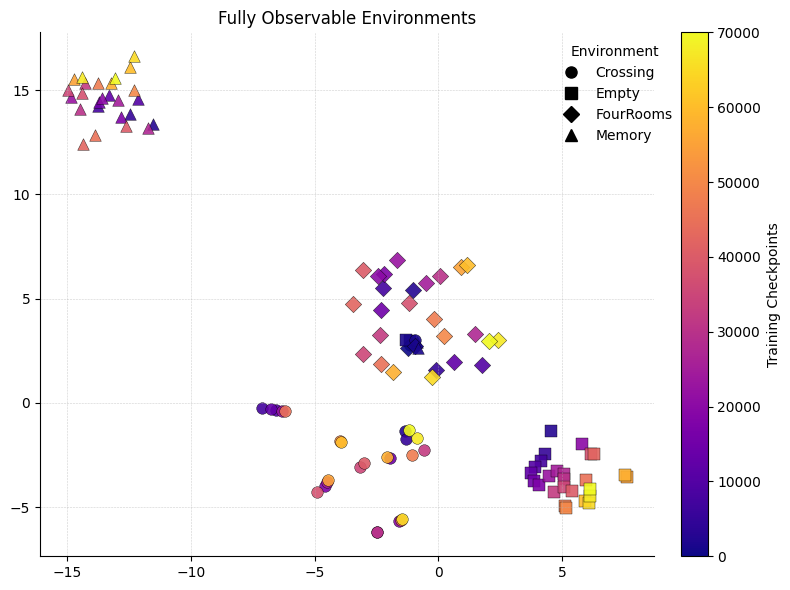

In [81]:
plot_TSNE(fullobs_emb_2d, fullobs_labels, "Fully Observable Environments")

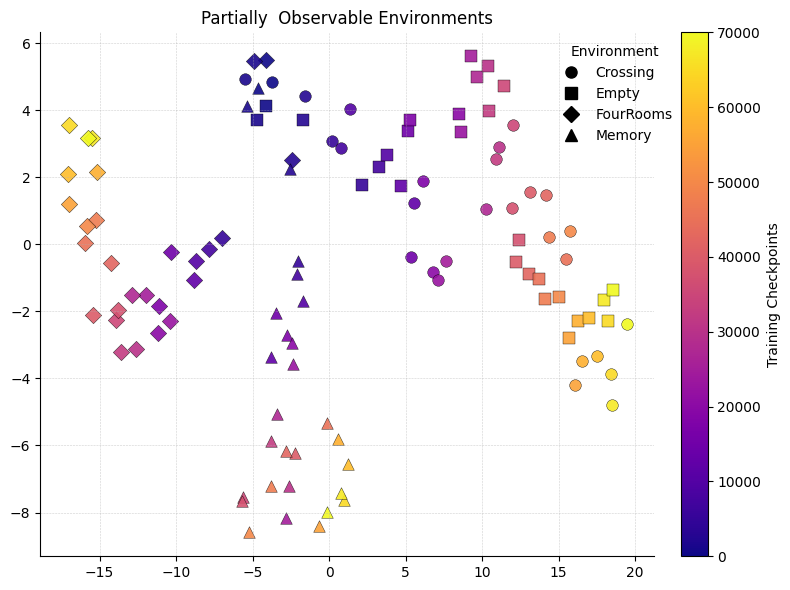

In [82]:
plot_TSNE(partialobs_emb_2d, partialobs_labels, "Partially  Observable Environments")

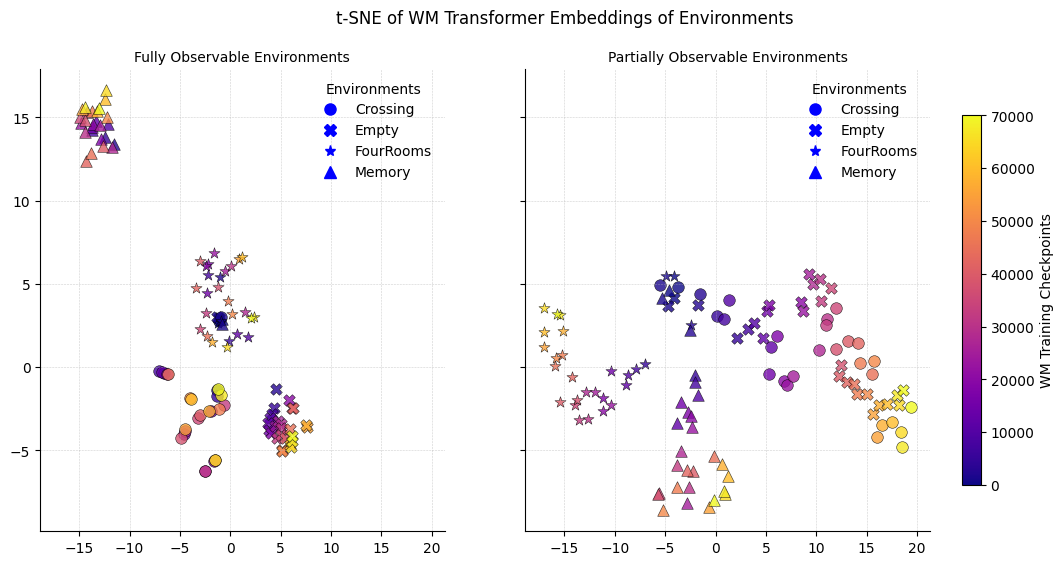

In [83]:
main_title = "t-SNE of WM Transformer Embeddings of Environments"
title_1 = "Fully Observable Environments"
title_2 = "Partially Observable Environments"
plot_TSNE_side_by_side(fullobs_emb_2d, partialobs_emb_2d, fullobs_labels, main_title, title_1, title_2)

# TEM Full and Partial

In [6]:
env_names = [
        "MiniGrid-Empty-8x8-v0",
        "MiniGrid-SimpleCrossingS9N1-v0",
        "MiniGrid-FourRooms-v0",
        "MiniGrid-MemoryS11-v0",
    ]
seed = 0
config_path = f"../config_files/STORM.yaml"
# pathes = glob.glob(f"{ckpt_root}/world_model_*.pth")
# steps = [int(path.split("_")[-1].split(".")[0]) for path in pathes]
# steps.sort()
# print(steps)
steps = [0, 1250, 2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000, 22500, 25000, 27500, 30000, 32500, 35000, 37500, 40000, 42500, 45000, 47500, 50000, 55000, 57500, 60000, 65000, 67500, 70000]


In [7]:
fullobs_RUN_NAME = "MultiEnv-FullObs-TEM-v1" #"EmptyFullObs-Baseline_v1" # "MemoryFullObs-Baseline_v1" #
fullobs_ckpt_root = f"../ckpt/{fullobs_RUN_NAME}/"
fullobs_run_params = RunParams(env_names, fullobs_RUN_NAME, config_path)

fullobs_emb, fullobs_labels = get_env_embddings(fullobs_run_params, fullobs_ckpt_root, steps, max_episode=16)
fullobs_emb_2d = calculate_TSNE(fullobs_emb)

Arguments:
-----------------
run_name: MultiEnv-FullObs-TEM-v1
seed: 1
env_name: 
['MiniGrid-Empty-8x8-v0', 'MiniGrid-SimpleCrossingS9N1-v0', 'MiniGrid-FourRooms-v0', 'MiniGrid-MemoryS11-v0']
-----------------


100%|██████████| 28/28 [00:23<00:00,  1.22it/s]


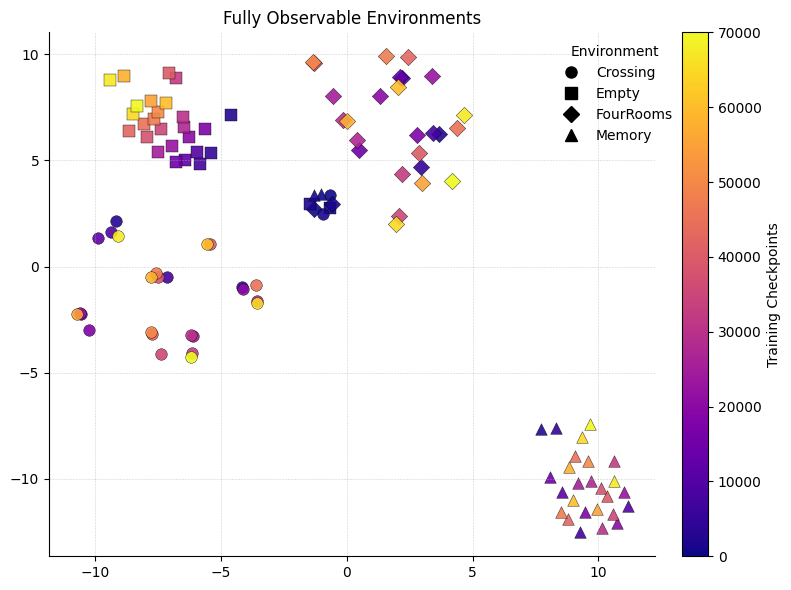

In [8]:
plot_TSNE(fullobs_emb_2d, fullobs_labels, "Fully Observable Environments")

In [10]:
partialobs_RUN_NAME = "MultiEnv-PartObs-TEM-v1"
partialobs_ckpt_root = f"../ckpt/{partialobs_RUN_NAME}/"


partialobs_run_params = RunParams(env_names, partialobs_RUN_NAME, config_path)
partialobs_emb, partialobs_labels = get_env_embddings(partialobs_run_params, partialobs_ckpt_root, steps, max_episode=16)
partialobs_emb_2d = calculate_TSNE(partialobs_emb)

Arguments:
-----------------
run_name: MultiEnv-PartObs-TEM-v1
seed: 1
env_name: 
['MiniGrid-Empty-8x8-v0', 'MiniGrid-SimpleCrossingS9N1-v0', 'MiniGrid-FourRooms-v0', 'MiniGrid-MemoryS11-v0']
-----------------


100%|██████████| 28/28 [00:22<00:00,  1.24it/s]


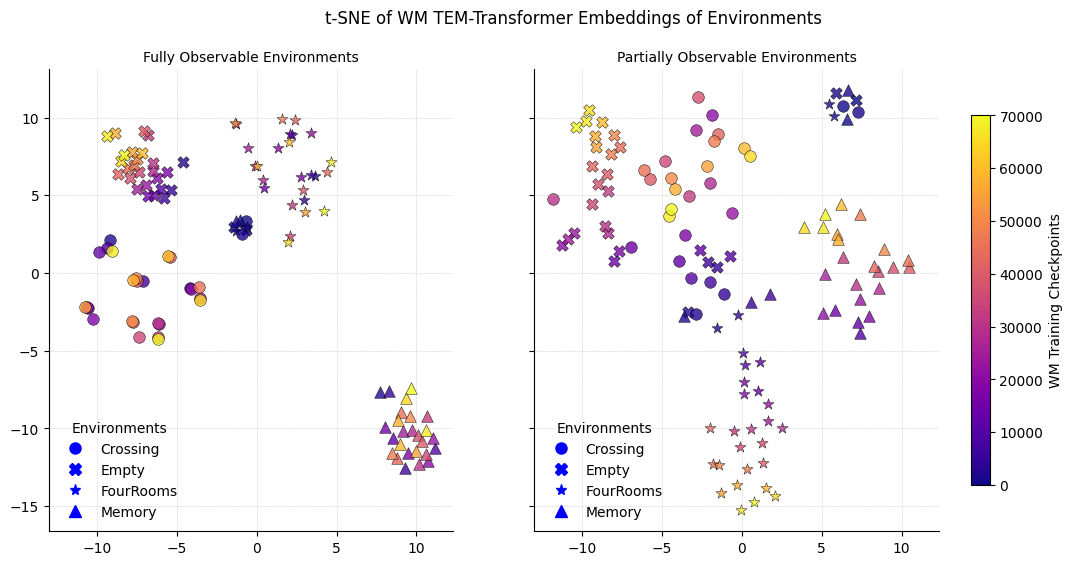

In [11]:
main_title = "t-SNE of WM TEM-Transformer Embeddings of Environments"
title_1 = "Fully Observable Environments"
title_2 = "Partially Observable Environments"
plot_TSNE_side_by_side(fullobs_emb_2d, partialobs_emb_2d, fullobs_labels, main_title, title_1, title_2)